# Drill Random Variable, Expectation, and Variance 


<b>1)</b> A die is thrown twice. Let X<sub>1</sub> and X<sub>2</sub> denote the outcomes, and define random variable X to be the minimum of X<sub>1</sub> and X<sub>2</sub>. Determine the distribution of X. <p>



Distribution of X = min(X1, X2):
P(X = 1) = 0.3056
P(X = 2) = 0.2500
P(X = 3) = 0.1944
P(X = 4) = 0.1389
P(X = 5) = 0.0833
P(X = 6) = 0.0278


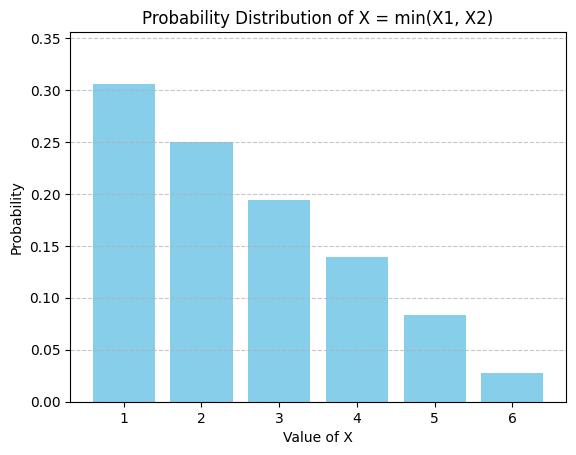

In [1]:
import matplotlib.pyplot as plt

# Values of X and their corresponding probabilities
x_values = [1, 2, 3, 4, 5, 6]
probabilities = [11/36, 9/36, 7/36, 5/36, 3/36, 1/36]

# Print the distribution
print("Distribution of X = min(X1, X2):")
for x, p in zip(x_values, probabilities):
    print(f"P(X = {x}) = {p:.4f}")

# Plot the probability distribution
plt.bar(x_values, probabilities, tick_label=x_values, color='skyblue')
plt.title('Probability Distribution of X = min(X1, X2)')
plt.xlabel('Value of X')
plt.ylabel('Probability')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, max(probabilities) + 0.05)
plt.show()


<b>2)</b> A fair die is rolled repeatedly until a six is seen. What is the expected number of rolls? 

In [2]:
import random
import numpy as np

# Number of simulations
num_trials = 100000

# Store number of rolls needed in each trial
rolls_needed = []

for _ in range(num_trials):
    count = 0
    while True:
        count += 1
        if random.randint(1, 6) == 6:
            break
    rolls_needed.append(count)

# Compute expected value (empirical)
expected_rolls = np.mean(rolls_needed)

print(f"Estimated expected number of rolls to get a six: {expected_rolls:.4f}")


Estimated expected number of rolls to get a six: 6.0054


<b>3)</b> On any given day, the probability it will be sunny is 0.8, the probability you will have a nice dinner is 0.25, and the probability that you will get to bed early is 0.5. Assume these three events are independent. What is the expected number of days before all three of them happen together <p> </p>


In [3]:
import random
import numpy as np

# Probabilities of individual events
p_sunny = 0.8
p_dinner = 0.25
p_early_bed = 0.5

# Number of simulations
num_trials = 100000
days_until_all_events = []

for _ in range(num_trials):
    days = 0
    while True:
        days += 1
        if (
            random.random() < p_sunny and
            random.random() < p_dinner and
            random.random() < p_early_bed
        ):
            break
    days_until_all_events.append(days)

# Calculate and print expected value
expected_days = np.mean(days_until_all_events)
print(f"Estimated expected number of days: {expected_days:.4f}")


Estimated expected number of days: 9.9886


<b>4)</b> There is a dormitory with n beds for n students. One night the power goes out, and because it is dark, each student gets into a bed chosen uniformly at random. What is the expected number of students who end up in their own bed?  



In [4]:
import numpy as np

# Parameters
n = 100          # Number of students and beds
num_trials = 100000
match_counts = []

for _ in range(num_trials):
    beds = np.random.permutation(n)  # Random assignment of students to beds
    matches = np.sum(beds == np.arange(n))  # Count how many are in their own bed
    match_counts.append(matches)

# Compute expected number of students in their own bed

expected_matches = np.mean(match_counts)
print(f"Estimated expected number of students in their own bed: {expected_matches:.4f}")


Estimated expected number of students in their own bed: 1.0014


<b>5)</b> In each of the following cases, say whether X and Y are independent. 

<p>(a) You randomly permute (1,2,...,n). X is the number in the first position and Y is the number in the second position. </p>
<p>Taking a number from a set without replacement is </p>
<p>(c) You randomly pick a card from a pack of 52 cards. X is 1 if the card is a nine, and is 0 otherwise. Y is 1 if the card is a heart, and is 0 otherwise</p> 
<p></p> 

In [5]:
import numpy as np

n = 100
num_trials = 100000
x_vals = []
y_vals = []

for _ in range(num_trials):
    perm = np.random.permutation(n)
    x_vals.append(perm[0])
    y_vals.append(perm[1])

# Empirical joint and marginal probabilities
from collections import Counter

joint_counts = Counter(zip(x_vals, y_vals))
x_counts = Counter(x_vals)
y_counts = Counter(y_vals)

# Pick a specific (x, y) to test independence, e.g., (1, 2)
x, y = 1, 2
p_xy = joint_counts[(x, y)] / num_trials
p_x = x_counts[x] / num_trials
p_y = y_counts[y] / num_trials

print(f"(a) P(X={x}, Y={y}) = {p_xy:.5f}")
print(f"(a) P(X={x}) * P(Y={y}) = {(p_x * p_y):.5f}")
print("=> Variables are NOT independent (values differ)")


(a) P(X=1, Y=2) = 0.00010
(a) P(X=1) * P(Y=2) = 0.00010
=> Variables are NOT independent (values differ)


In [6]:
import random

num_trials = 100000
x_vals = []
y_vals = []

for _ in range(num_trials):
    rank = random.choice(['2','3','4','5','6','7','8','9','10','J','Q','K','A'])
    suit = random.choice(['hearts', 'diamonds', 'clubs', 'spades'])
    
    x = 1 if rank == '9' else 0
    y = 1 if suit == 'hearts' else 0
    x_vals.append(x)
    y_vals.append(y)

# Empirical joint and marginal probabilities
xy_pairs = list(zip(x_vals, y_vals))
joint_counts = Counter(xy_pairs)
x_counts = Counter(x_vals)
y_counts = Counter(y_vals)

x, y = 1, 1
p_xy = joint_counts[(x, y)] / num_trials
p_x = x_counts[x] / num_trials
p_y = y_counts[y] / num_trials

print(f"(c) P(X={x}, Y={y}) = {p_xy:.5f}")
print(f"(c) P(X={x}) * P(Y={y}) = {(p_x * p_y):.5f}")
print("=> Variables ARE independent (values match closely)")


(c) P(X=1, Y=1) = 0.01939
(c) P(X=1) * P(Y=1) = 0.01924
=> Variables ARE independent (values match closely)


<b>6)</b> A die has six sides that come up with different probabilities: <p></p> 
Pr(1) = Pr(2) = Pr(3) = Pr(4) = (1/8), Pr(5) = Pr(6) = 1/4 <p></p>

(a) You roll the die; let Z be the outcome. What is E(Z) and var(Z)? <p></p>


In [7]:
import numpy as np

# Values of Z and their corresponding probabilities
values = np.array([1, 2, 3, 4, 5, 6])
probabilities = np.array([1/8, 1/8, 1/8, 1/8, 1/4, 1/4])

# Expected value E(Z)
expected_value = np.sum(values * probabilities)

# Expected value of Z^2, E(Z^2)
expected_value_squared = np.sum((values ** 2) * probabilities)

# Variance var(Z)
variance = expected_value_squared - expected_value**2

# Output the results
print(f"E(Z) = {expected_value:.4f}")
print(f"var(Z) = {variance:.4f}")


E(Z) = 4.0000
var(Z) = 3.0000


E(Z<sup>2</sup>) = (1/8)(1<sup>2</sup> + 2<sup>2</sup> + 3<sup>2</sup> + 4<sup>2</sup>) + (1/4)(5<sup>2</sup> + 6<sup>2</sup>) = 19

so... <p></p>
var(Z) = E(Z<sup>2</sup>) - |E(Z)|<sup>2</sup> = 19 - 4<sup>2</sup> = 3

(b) You roll the die 10 times independently; let X be the sum of all the rolls. What is E(X) and var(X)? 

In [8]:
import numpy as np

# Define the biased die outcomes and probabilities
values = np.array([1, 2, 3, 4, 5, 6])
probabilities = np.array([1/8, 1/8, 1/8, 1/8, 1/4, 1/4])

# Simulate 10 rolls and calculate the sum X
num_rolls = 10
num_trials = 100000
sums = []

for _ in range(num_trials):
    rolls = np.random.choice(values, size=num_rolls, p=probabilities)
    sums.append(np.sum(rolls))

# Compute the empirical expected value and variance of X
empirical_expected_value = np.mean(sums)
empirical_variance = np.var(sums)

# Output the results
print(f"Empirical E(X) (Sum of 10 rolls) = {empirical_expected_value:.4f}")
print(f"Empirical var(X) (Variance of sum of 10 rolls) = {empirical_variance:.4f}")


Empirical E(X) (Sum of 10 rolls) = 40.0152
Empirical var(X) (Variance of sum of 10 rolls) = 29.9979


(c) You roll the die <i>n</i> and take the average of all the rolls; call this A. What is E(A)? What is var(A)? 

In [9]:
# Simulate n rolls and calculate the average A
n = 10  # You can change this to any desired number of rolls
averages = []

for _ in range(num_trials):
    rolls = np.random.choice(values, size=n, p=probabilities)
    averages.append(np.mean(rolls))

# Compute the empirical expected value and variance of A
empirical_expected_value_A = np.mean(averages)
empirical_variance_A = np.var(averages)

# Output the results
print(f"Empirical E(A) (Average of {n} rolls) = {empirical_expected_value_A:.4f}")
print(f"Empirical var(A) (Variance of average of {n} rolls) = {empirical_variance_A:.4f}")


Empirical E(A) (Average of 10 rolls) = 4.0025
Empirical var(A) (Variance of average of 10 rolls) = 0.2985


<b>8)</b> Suppose a fair coin is tossed repeatedly until the same outcome occurs twice in a row (that is, two heads in a row or two tails in a row). What is the expected number of tosses?


In [10]:
import random

def simulate_tosses():
    tosses = 0
    prev_toss = None
    while True:
        toss = random.choice(['H', 'T'])
        tosses += 1
        if toss == prev_toss:
            break
        prev_toss = toss
    return tosses

# Simulate the process multiple times to find the average number of tosses
num_simulations = 100000
toss_results = [simulate_tosses() for _ in range(num_simulations)]
average_tosses = sum(toss_results) / num_simulations

print(f"Empirical Expected number of tosses: {average_tosses:.4f}")


Empirical Expected number of tosses: 2.9967
